In [1]:
!pip install -qr requirements.txt

In [2]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.tune import tune

/home/jann/GAT/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [6]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [7]:
graphs = dict()

In [8]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [9]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [10]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

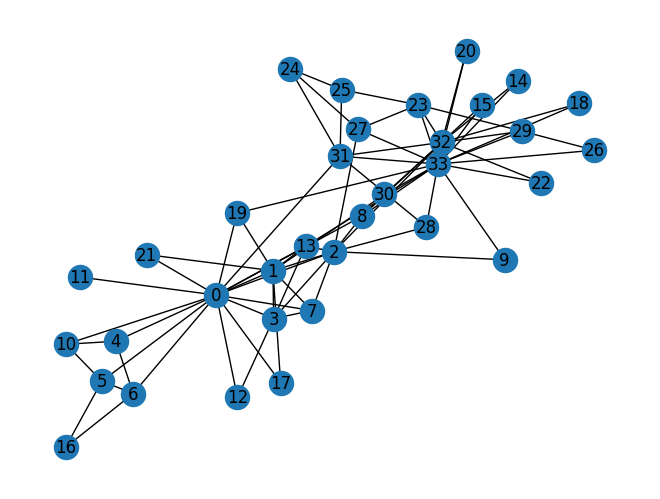

In [11]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

### single run

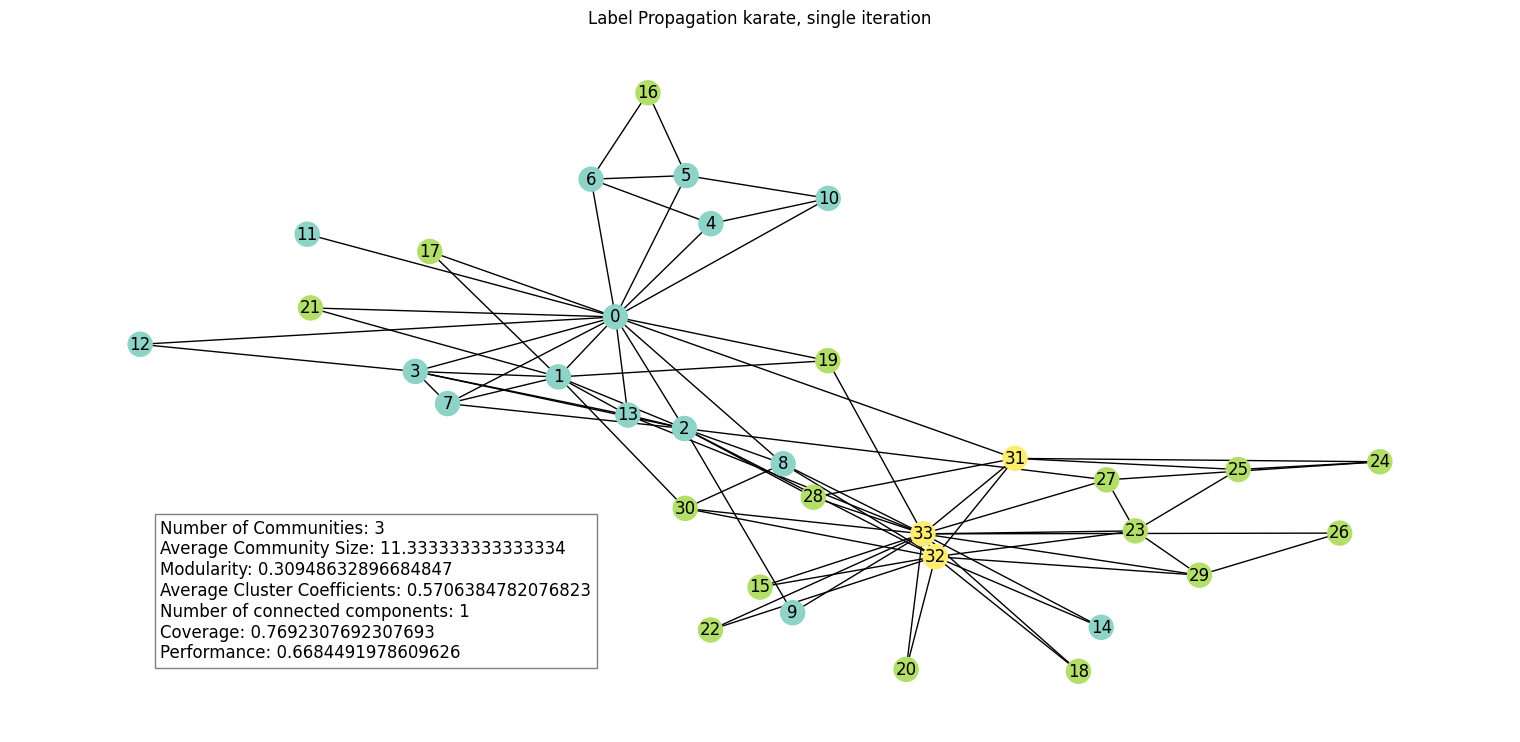

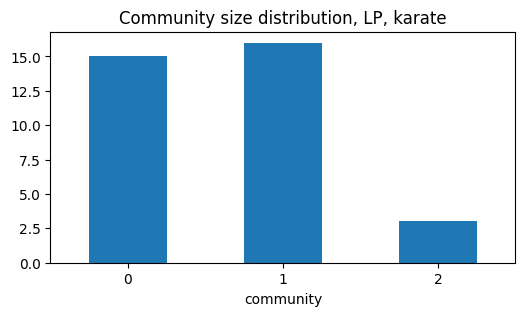

In [12]:
lp_labels = label_propagation(g)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

### with 5 iterations

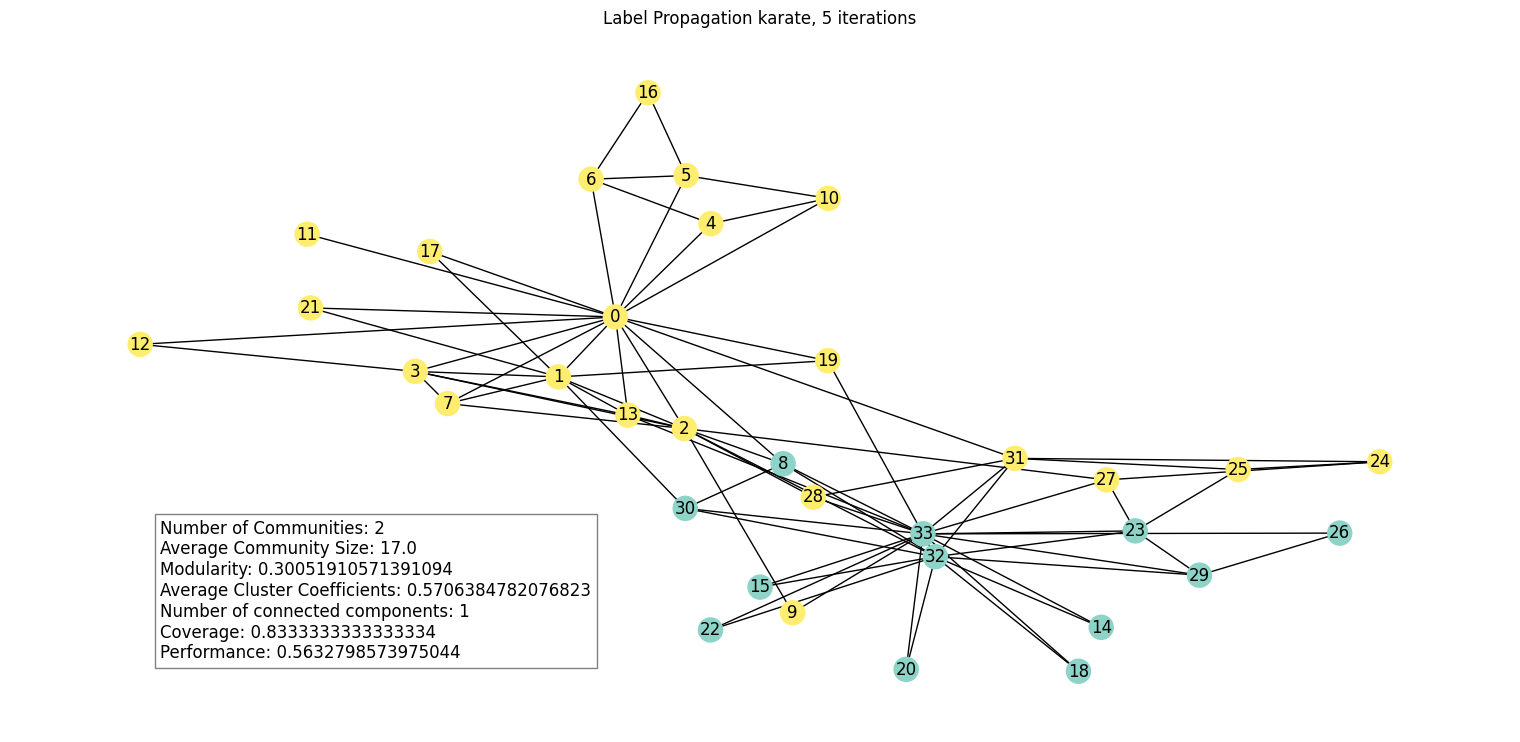

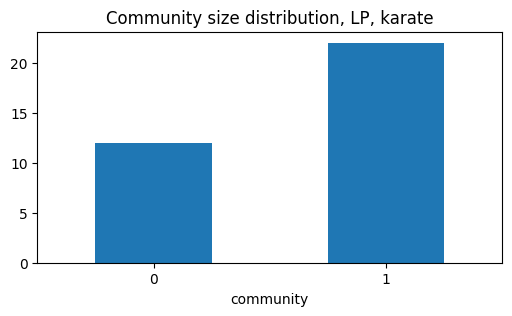

In [13]:
lp_labels = label_propagation(g, aggr_runs=5)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {5} iterations", metrics=lp_metrics)
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

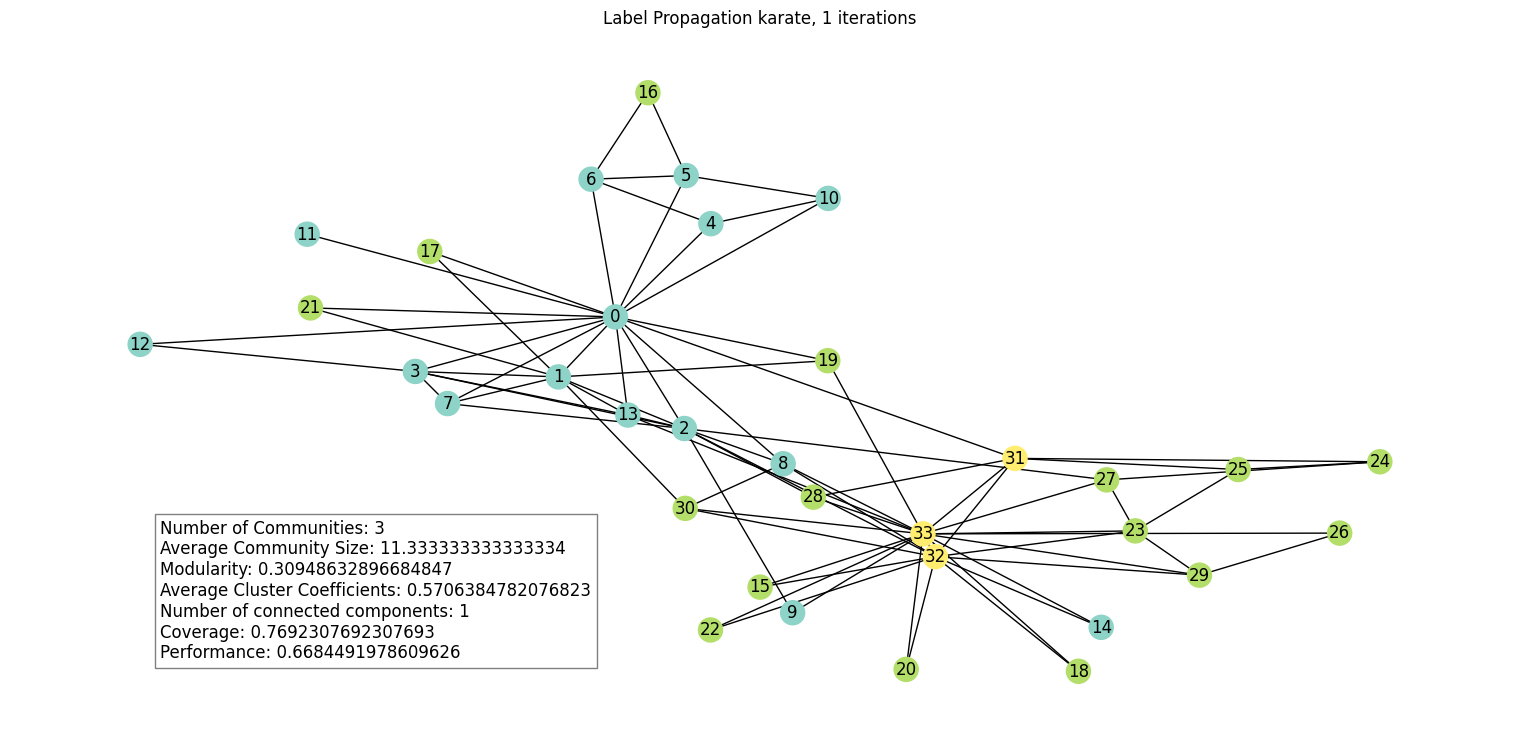

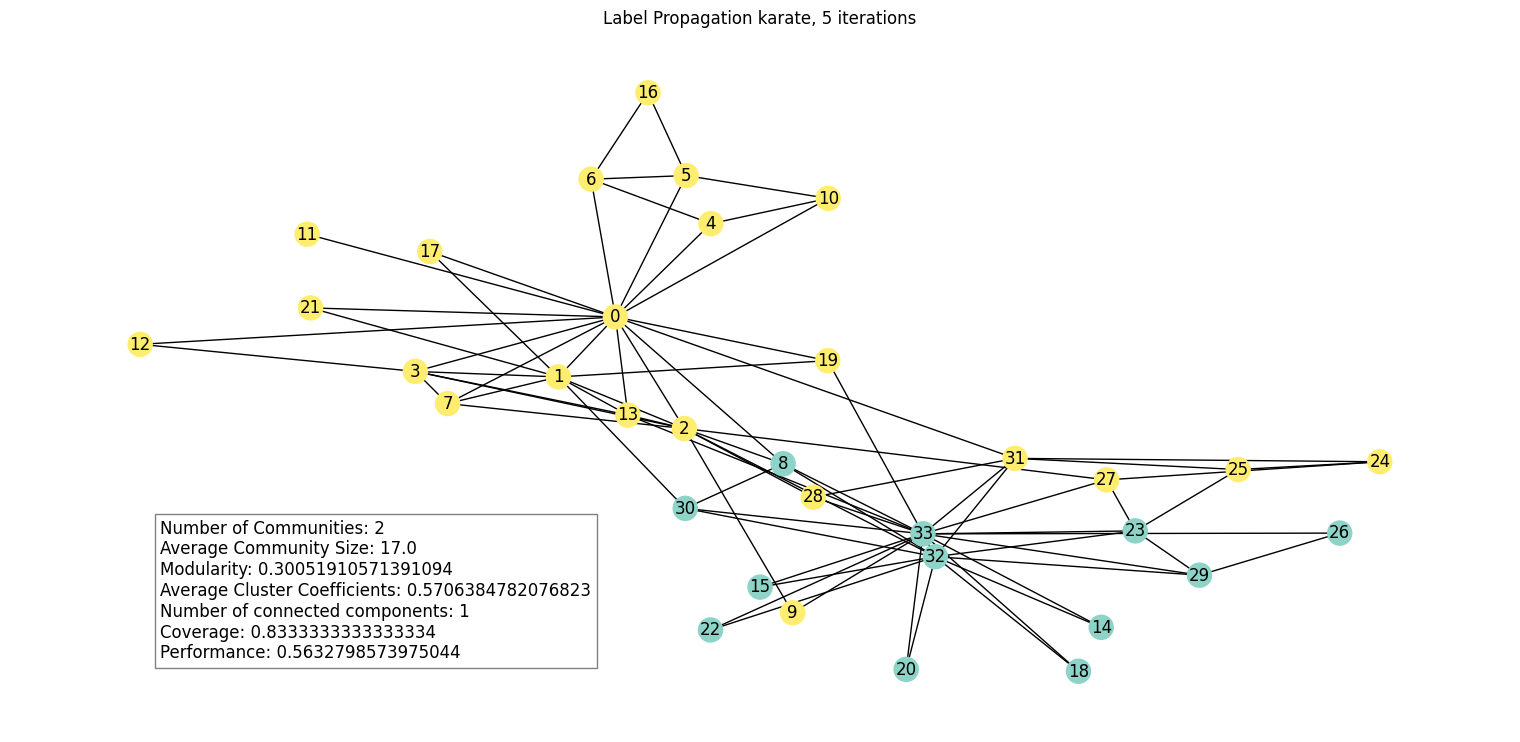

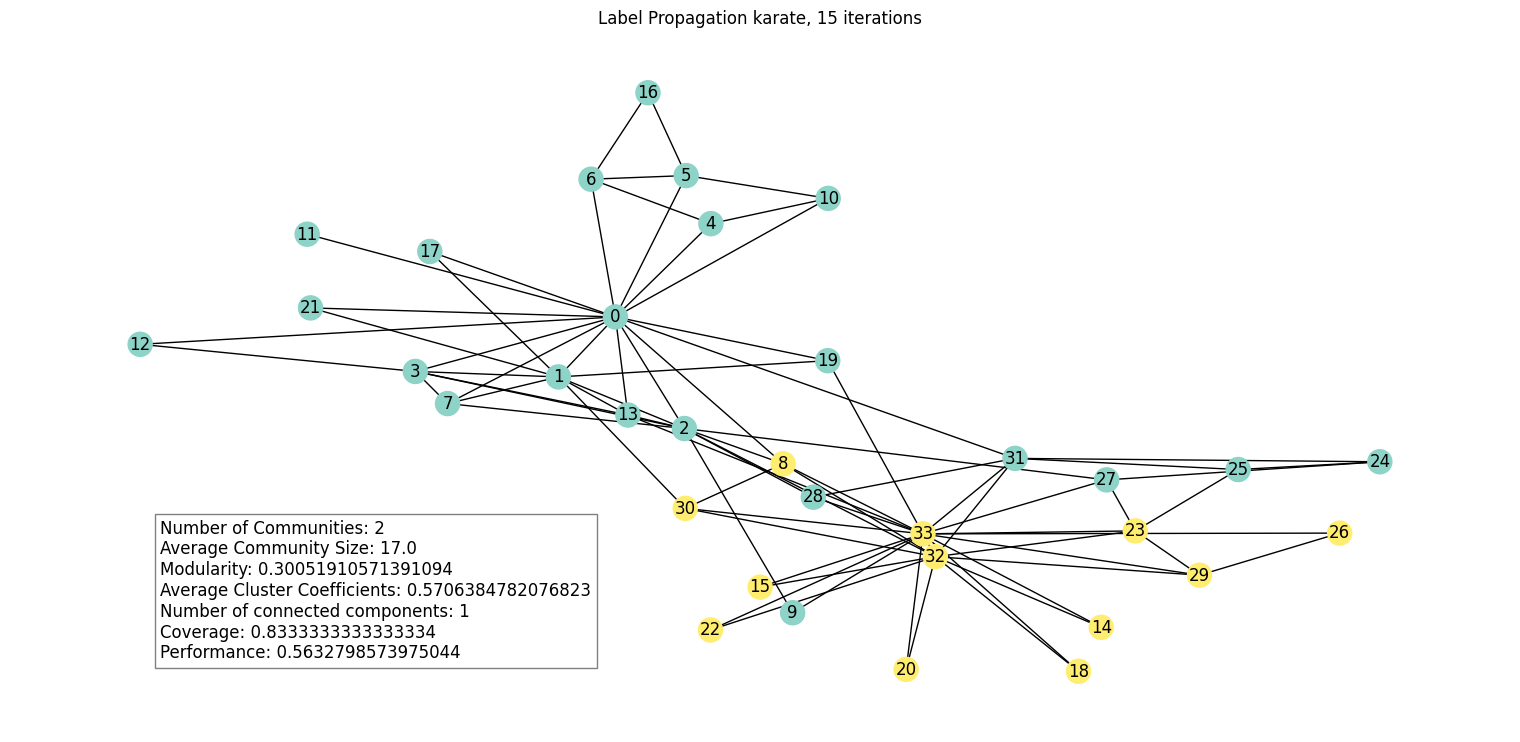

In [14]:
# 5 based on results in paper, experiments with higher value confirms their statement that it doesnt change much
for i in (1, 5, 15):
    lp_labels = label_propagation(g, aggr_runs=i)

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {i} iterations", metrics=lp_metrics)

## Louvain

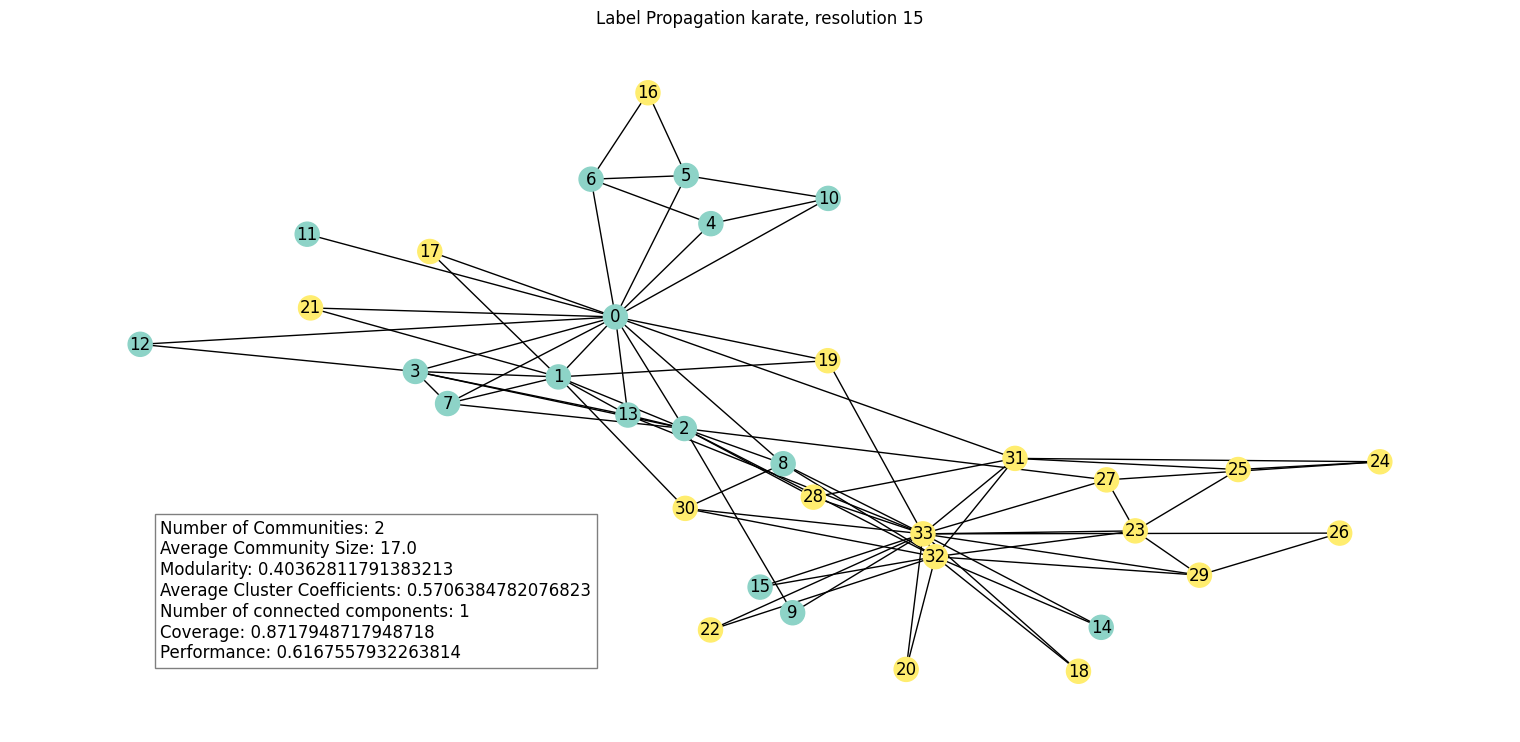

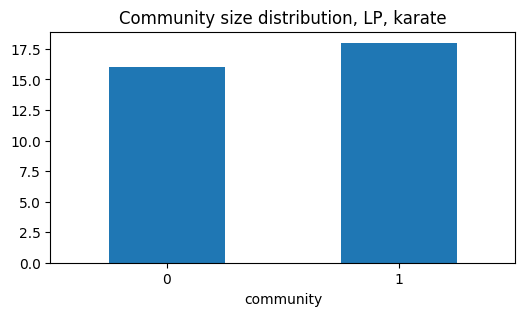

In [15]:
lv_labels = louvain(g, resolution=0.5)

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
plot_communities(g, lv_labels, title=f"Label Propagation {sel_graph}, resolution {i}", metrics=lv_metrics)
community_size_hist(lv_labels, title=f"Community size distribution, LP, {sel_graph}")

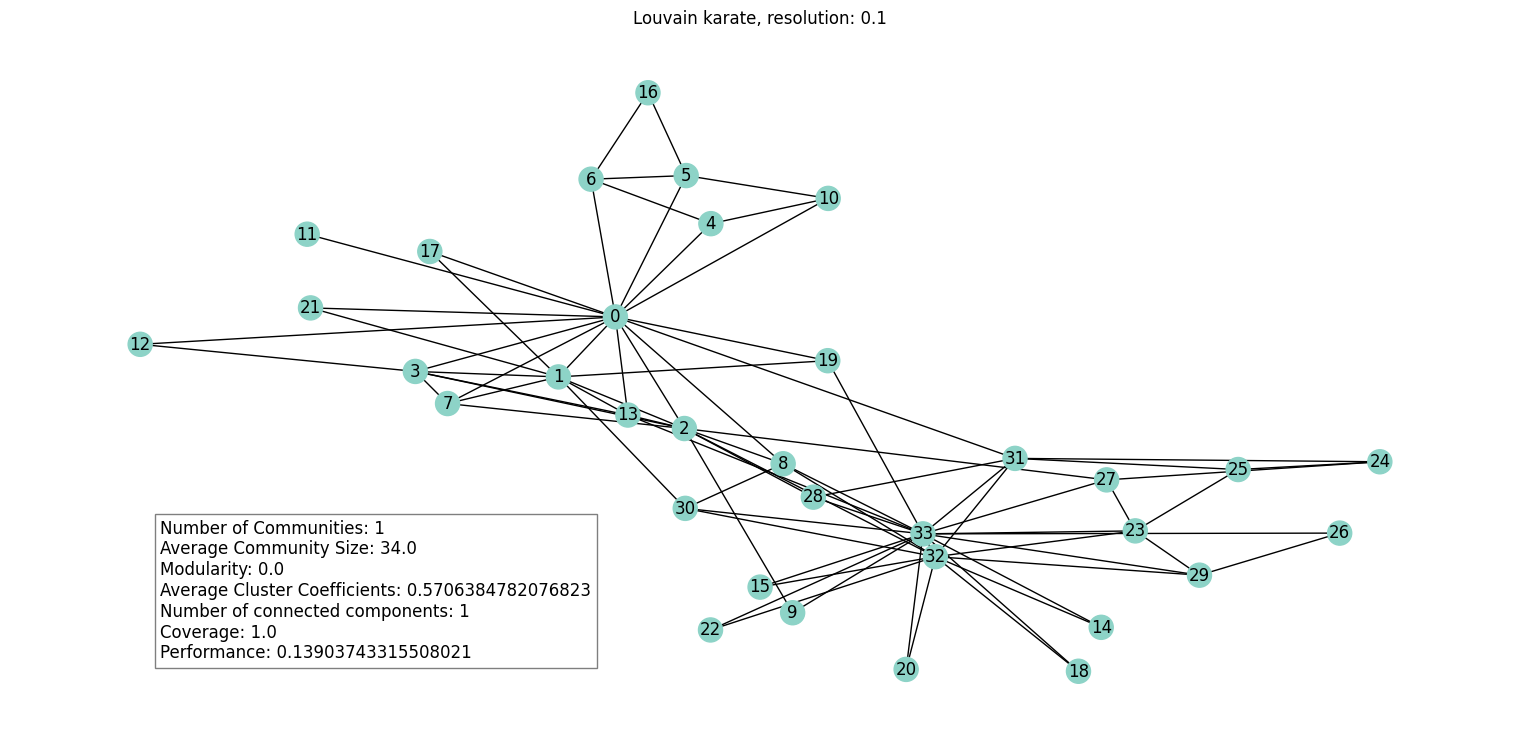

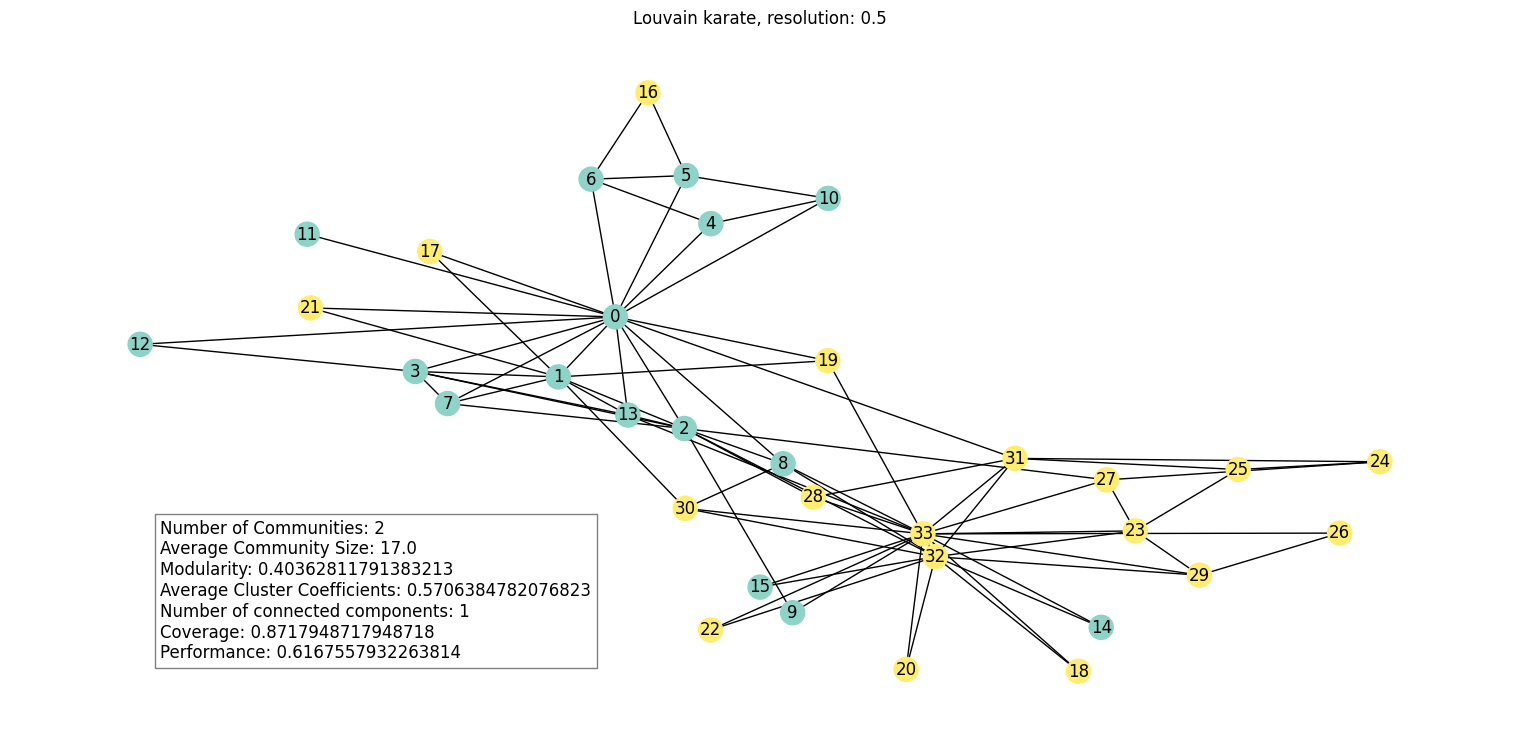

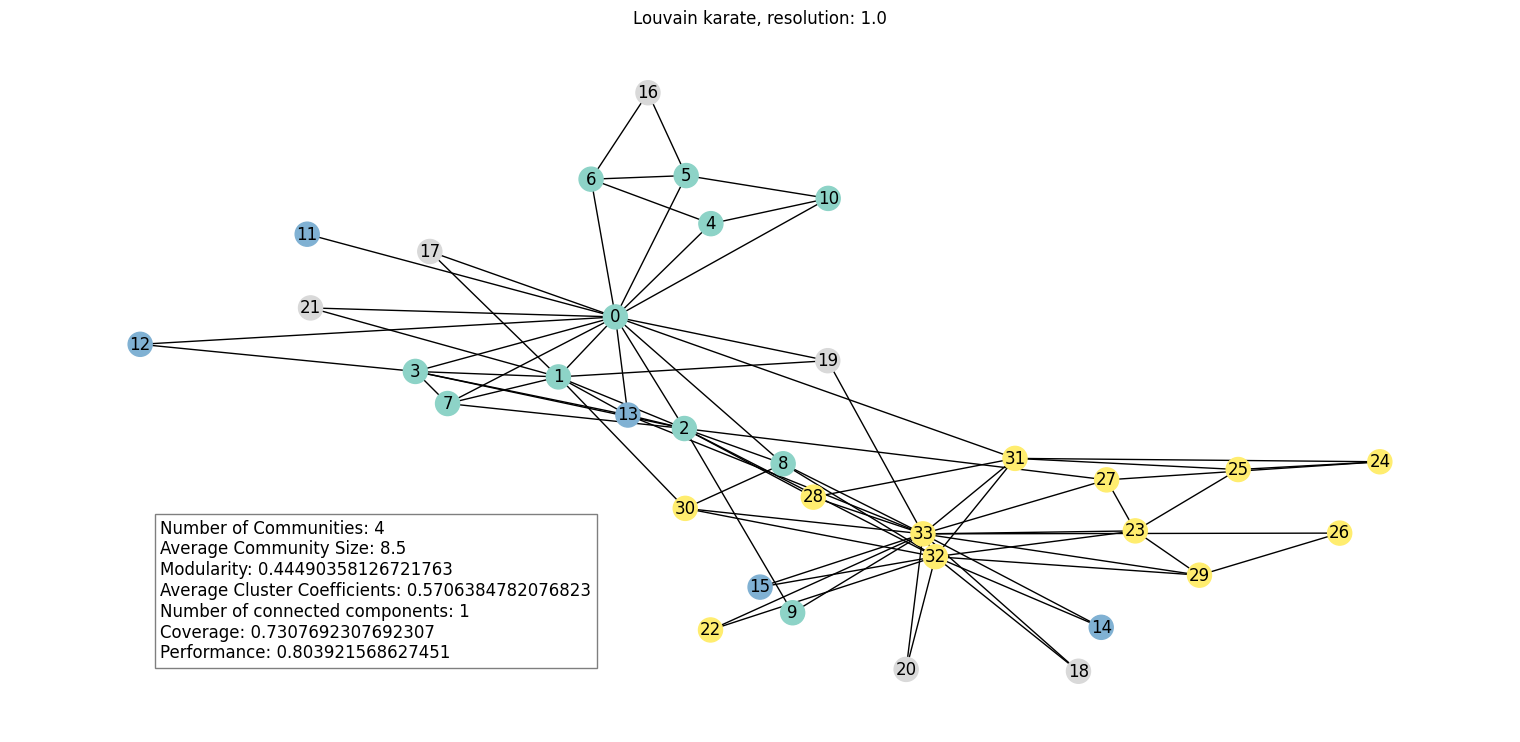

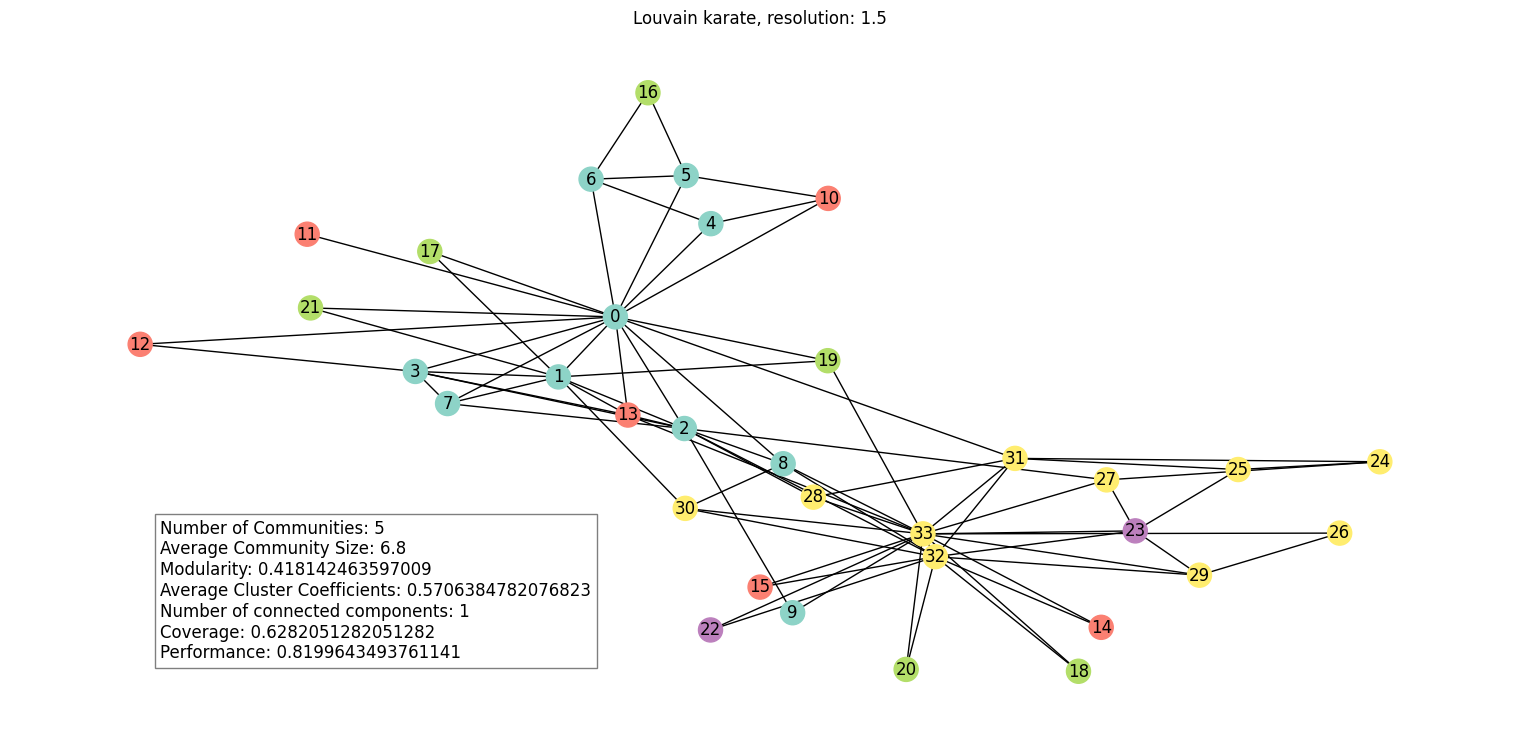

In [16]:
for i in (0.1, 0.5, 1.0, 1.5):
    lv_labels = louvain(g, resolution=i)

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    plot_communities(g, lv_labels, title=f"Louvain {sel_graph}, resolution: {i}", metrics=lv_metrics)


## Leiden

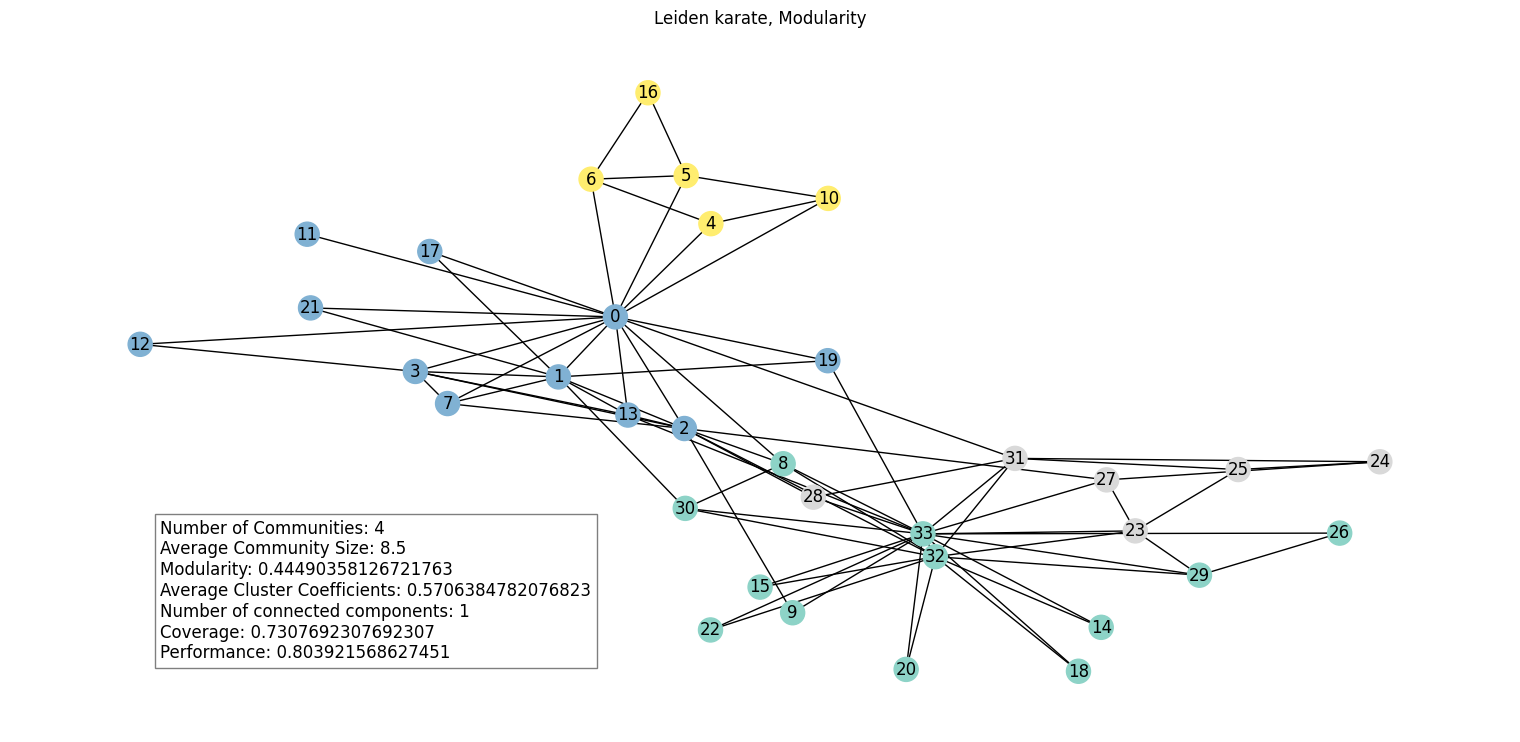

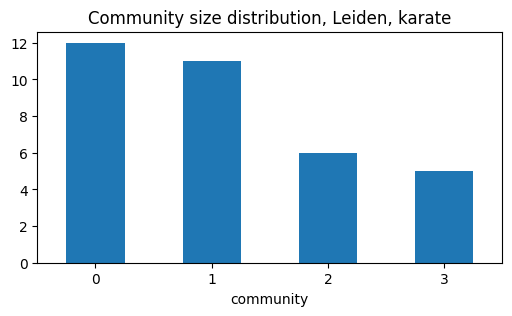

In [17]:
ld_labels = leiden(g)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, Modularity", metrics=ld_metrics)
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

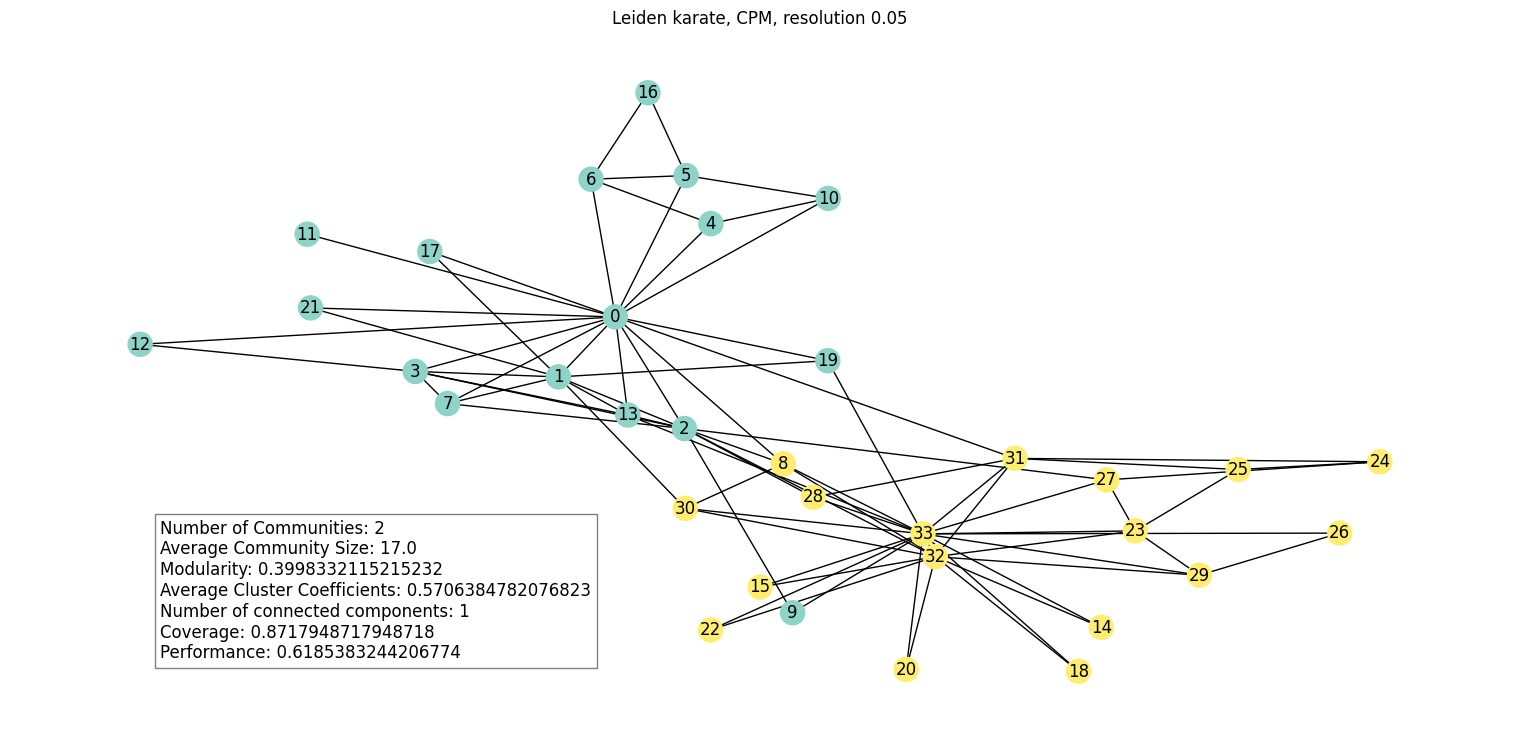

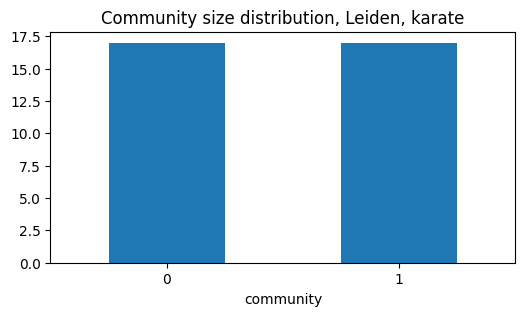

In [18]:
ld_labels = leiden(g, resolution=0.05)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {0.05}", metrics=ld_metrics)
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

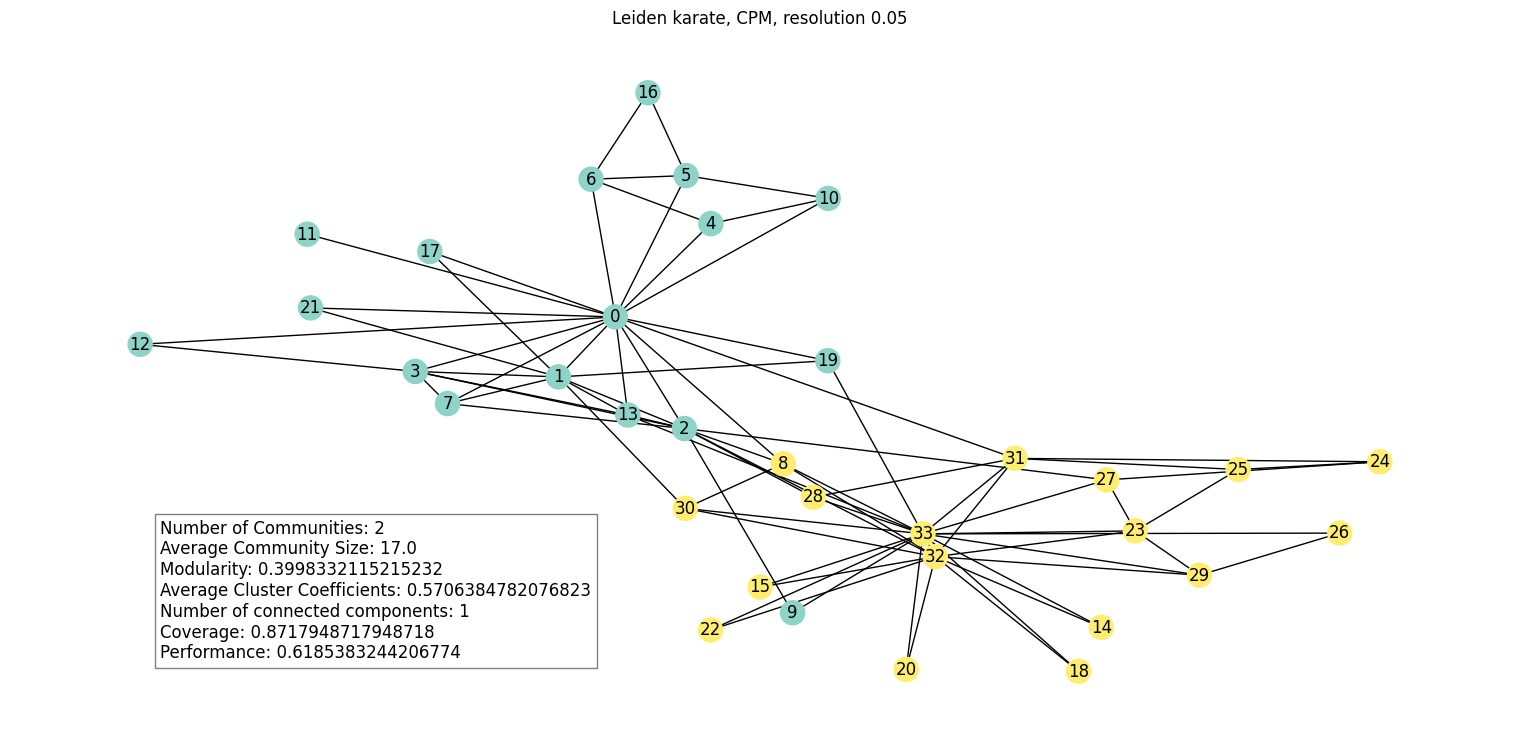

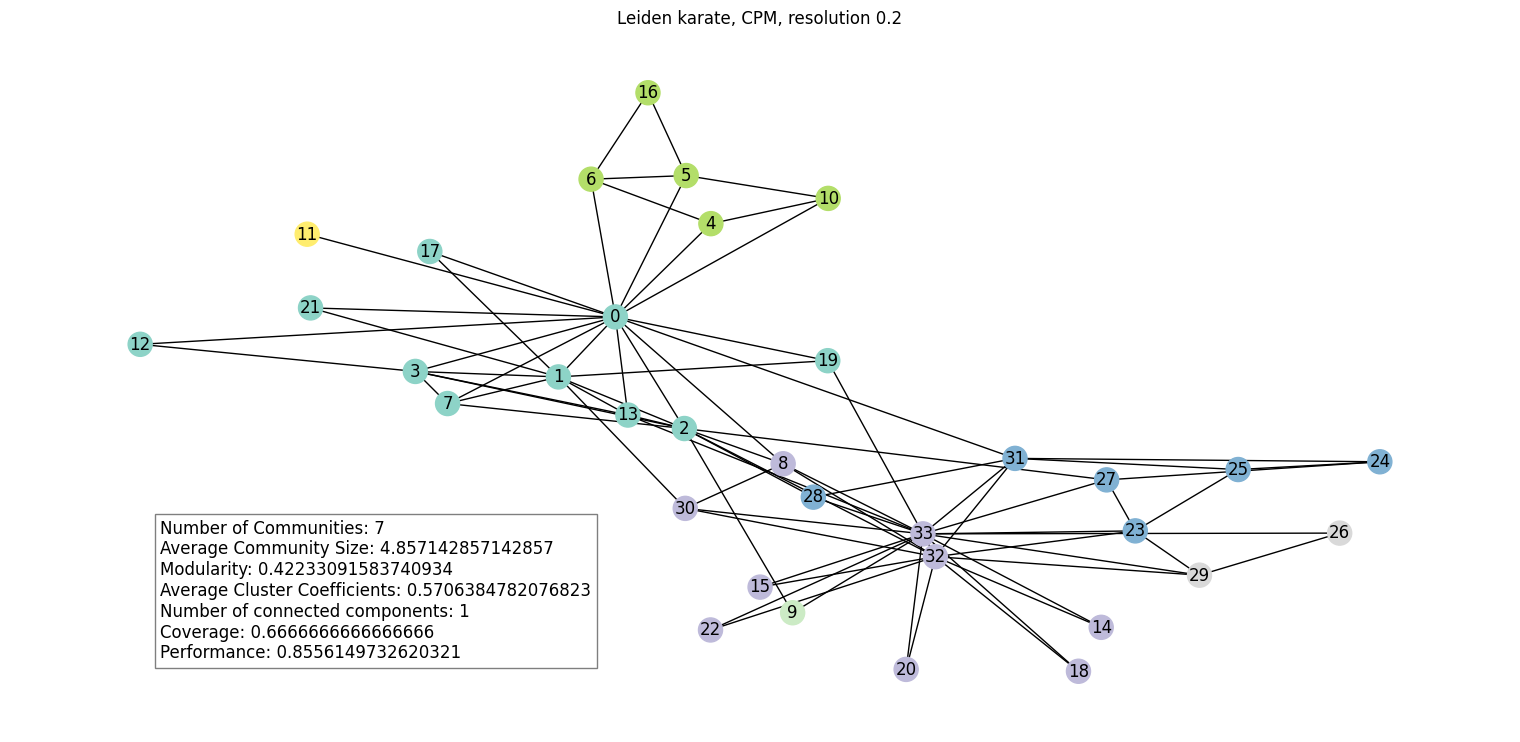

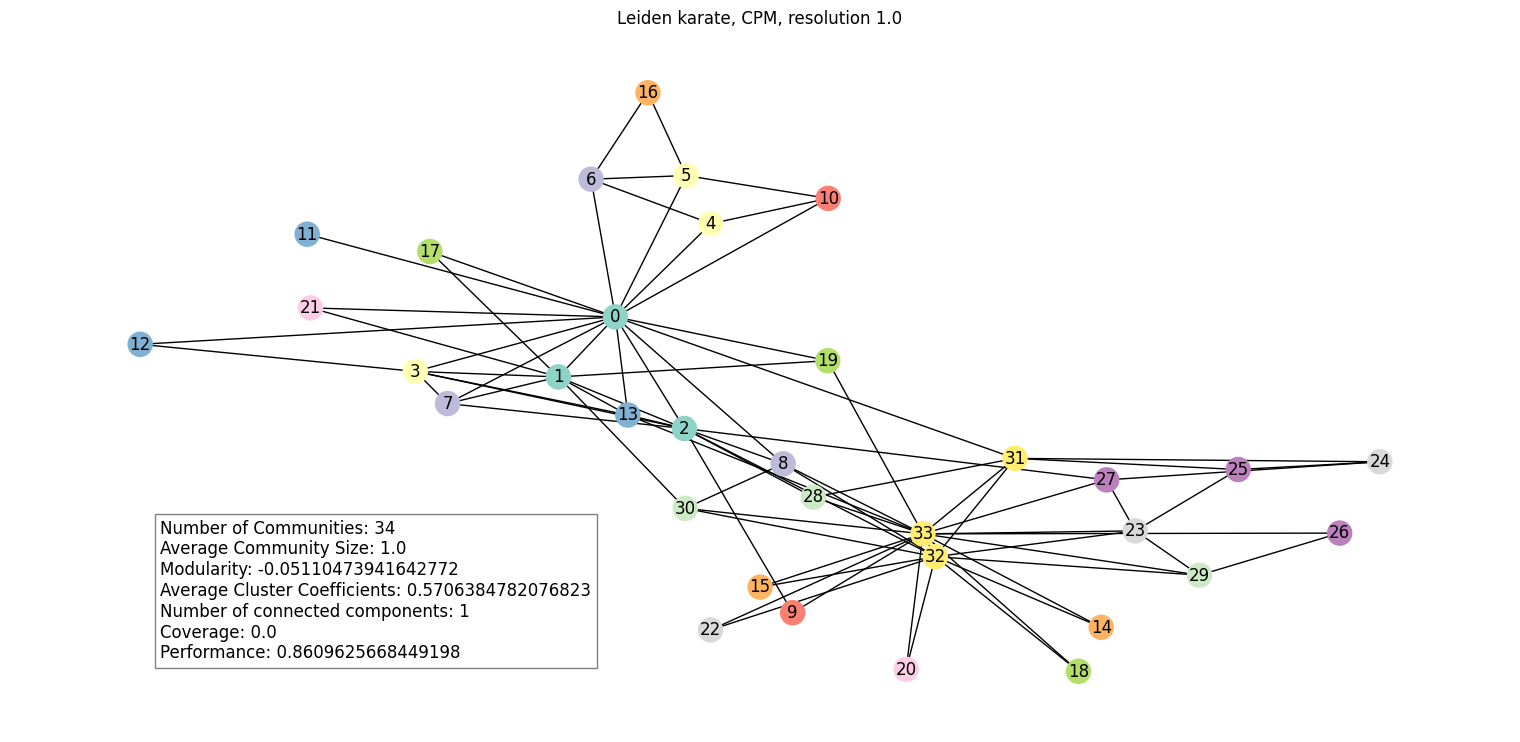

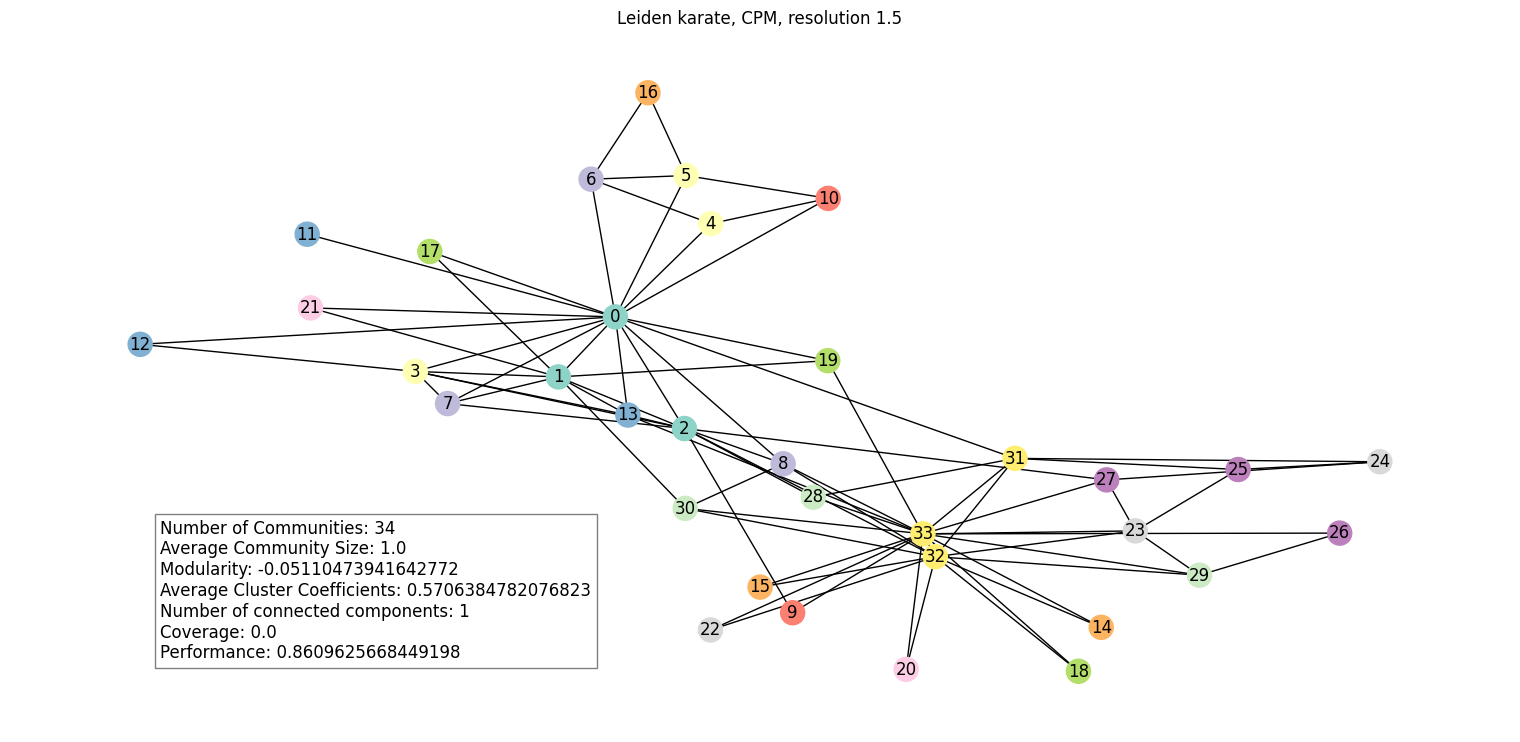

In [19]:
for i in (0.05, 0.2, 1.0, 1.5):
    ld_labels = leiden(g, resolution=i)

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {i}", metrics=ld_metrics)


# Apply GAT Embedding

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [21]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [22]:
best_parameters_optuna = tune(data)
best_parameters_optuna

[I 2024-08-12 16:46:39,167] A new study created in memory with name: no-name-6b183ca4-e7fb-4cd9-aff8-9ba802f18cbd
[I 2024-08-12 16:46:40,033] Trial 0 finished with value: 0.09960552268244577 and parameters: {'hidden_channels': 44, 'out_channels': 27, 'heads': 13, 'learning_rate': 0.00027516197157006746, 'dropout': 0.26993057828728445, 'weight_decay': 2.5188550246012874e-05}. Best is trial 0 with value: 0.09960552268244577.
[I 2024-08-12 16:46:40,313] Trial 1 finished with value: 0.3858481262327416 and parameters: {'hidden_channels': 41, 'out_channels': 15, 'heads': 2, 'learning_rate': 0.0004993745017498879, 'dropout': 0.14941448420226908, 'weight_decay': 3.914308537185956e-05}. Best is trial 1 with value: 0.3858481262327416.
[I 2024-08-12 16:46:40,883] Trial 2 finished with value: 0.3863412228796844 and parameters: {'hidden_channels': 18, 'out_channels': 14, 'heads': 11, 'learning_rate': 0.00010041580411154155, 'dropout': 0.3160496668288987, 'weight_decay': 0.00016499230538019851}. Bes

In [23]:
best_parameters_optuna.best_value

0.41978961209730437

In [24]:
best_parameters = best_parameters_optuna.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

In [25]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(epochs):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')

Epoch 0, Loss: 1.3944931030273438
Epoch 10, Loss: 1.3556923866271973
Epoch 20, Loss: 1.3212436437606812
Epoch 30, Loss: 1.383371353149414
Epoch 40, Loss: 1.3360705375671387
Epoch 50, Loss: 1.3388559818267822
Epoch 60, Loss: 1.3795676231384277
Epoch 70, Loss: 1.3464488983154297
Epoch 80, Loss: 1.3362154960632324
Epoch 90, Loss: 1.3551875352859497


In [26]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index).detach().cpu().numpy()

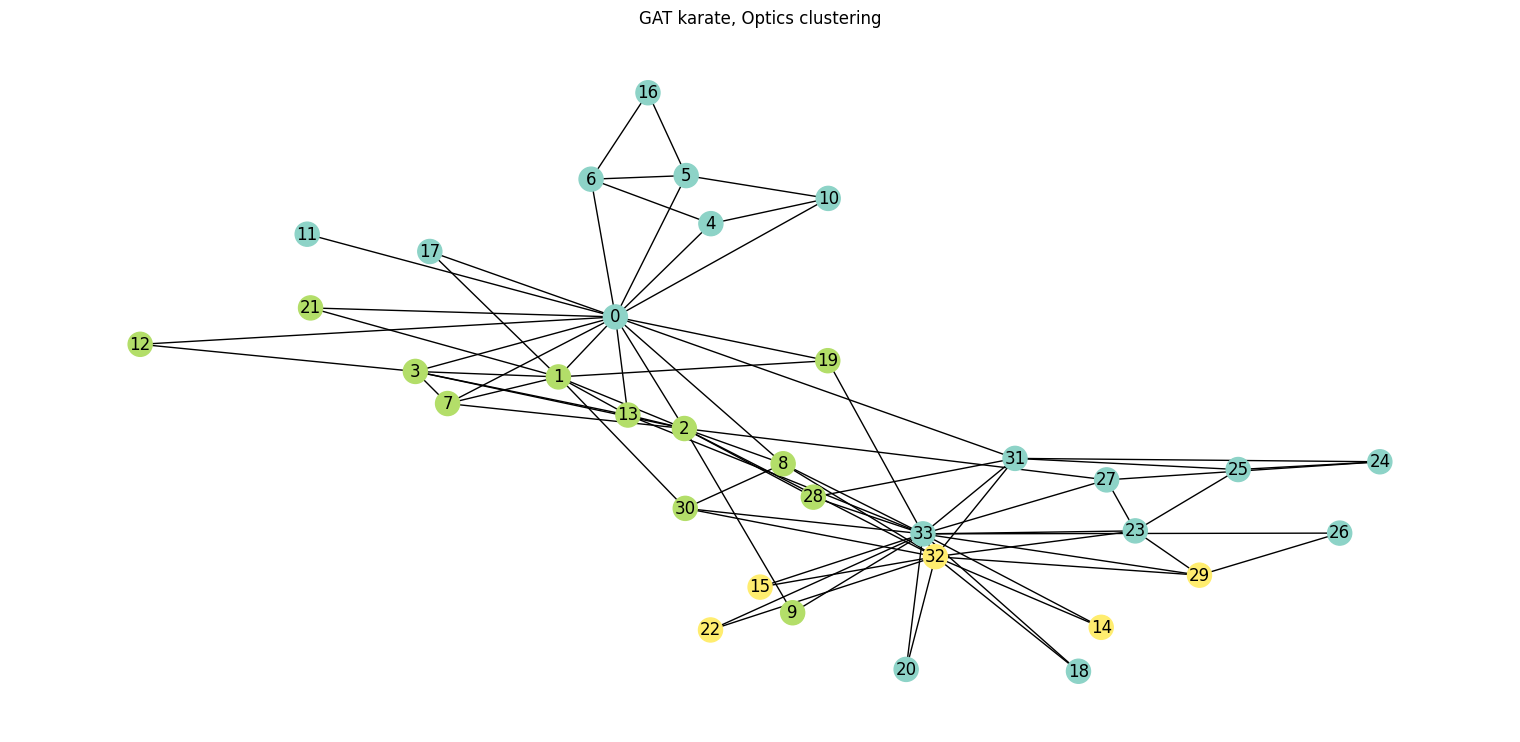

{'Number of Communities': 3,
 'Average Community Size': 11.333333333333334,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.2209104027285845,
 'Coverage': 0.5897435897435898,
 'Performance': 0.6470588235294118}

In [27]:
# optics clustering
modularity, best_n, gat_communities = optics(g, node_embeddings)

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, Optics clustering")
community_metrics(g, gat_communities)

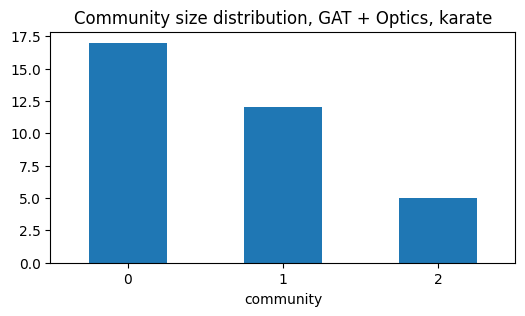

In [28]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + Optics, {sel_graph}")

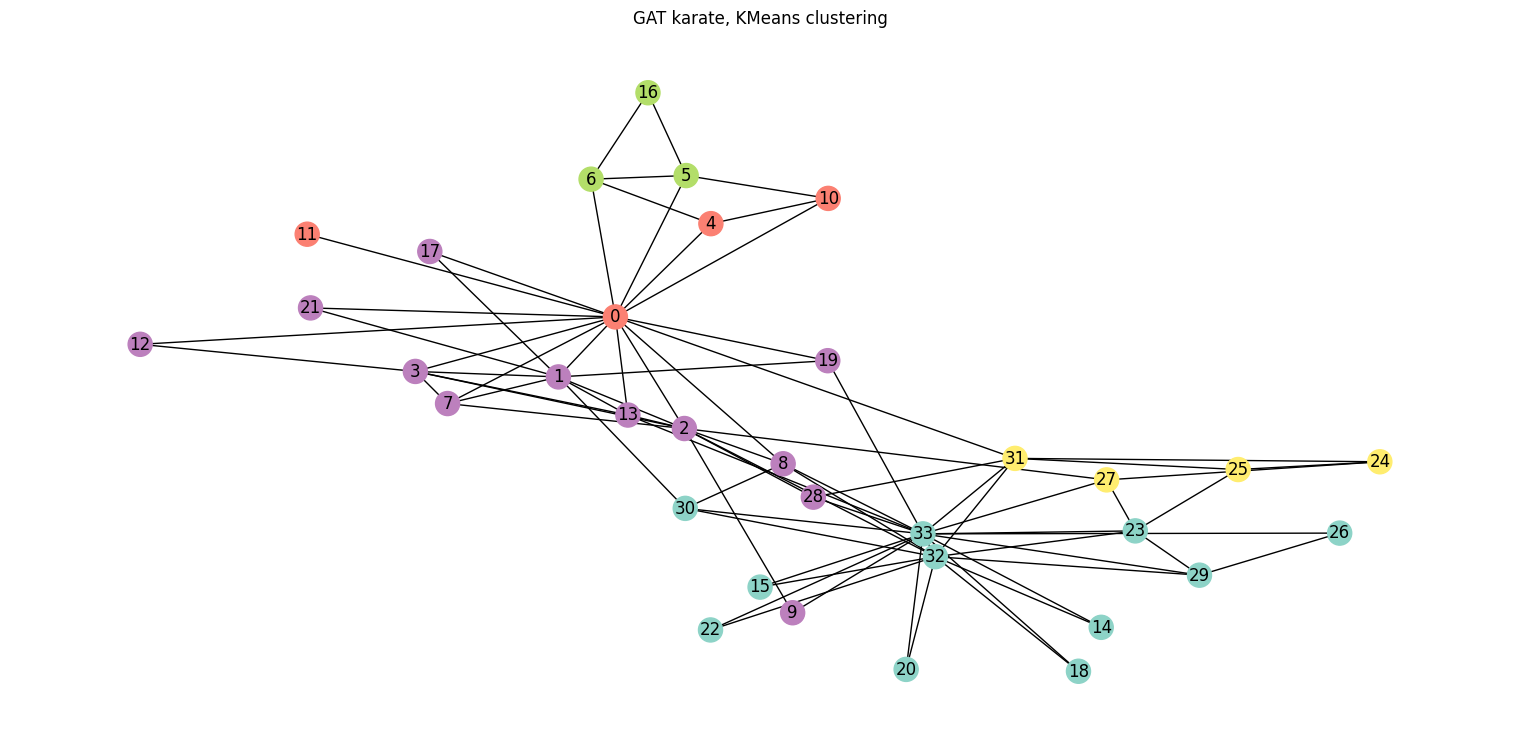

{'Number of Communities': 5,
 'Average Community Size': 6.8,
 'Average Cluster Coefficients': 0.5706384782076823,
 'Number of connected components': 1,
 'Modularity': 0.3613125691047769,
 'Coverage': 0.6025641025641025,
 'Performance': 0.786096256684492}

In [29]:
# kmeans clustering
modularity, best_n, gat_communities = kmeans(g, node_embeddings)

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, KMeans clustering")
community_metrics(g, gat_communities)

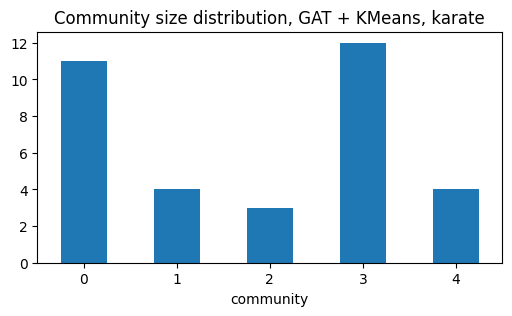

In [30]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + KMeans, {sel_graph}")

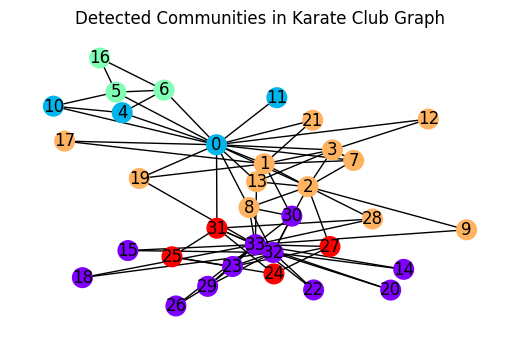

In [31]:
# Plotting the communities
plt.figure(figsize=(5, 3))
nx.draw(g, node_color=list(gat_communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title(f"Detected Communities in {sel_graph} Graph")
plt.show()